<a href="https://colab.research.google.com/github/DanielRegaladoUMiami/maya-encoding/blob/main/examples/04_benchmark_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmark Results: Maya Encoding vs Standard Approaches

This notebook demonstrates the performance of VFD and MCE encoders across multiple
datasets and model types. **Key insight:** use `passthrough=True` for tree-based models
to get the best of both worlds.

In [4]:
!pip install maya-encoding matplotlib

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from maya_encoding import VFDEncoder

## 1. VFD Benchmark: California Housing (with Passthrough Comparison)

We compare 5 encoding strategies across 4 model types to show when VFD helps
and when `passthrough=True` is critical.

In [6]:
# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target
print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')

# Define 5 encoding pipelines
pipelines = {
    'Raw + Scaled': Pipeline([('scale', MinMaxScaler())]),
    'VFD-lite': Pipeline([('encode', VFDEncoder(components='lite'))]),
    'VFD-full': Pipeline([('encode', VFDEncoder(components='full'))]),
    'VFD-lite + PT': Pipeline([('encode', VFDEncoder(components='lite', passthrough=True))]),
    'VFD-full + PT': Pipeline([('encode', VFDEncoder(components='full', passthrough=True))]),
}

# Define 4 models
models = {
    'LinearReg': LinearRegression(),
    'Ridge': Ridge(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# Run cross-validation
results = {}
for enc_name, enc_pipe in pipelines.items():
    for model_name, model in models.items():
        pipe = Pipeline([
            ('encode', enc_pipe),
            ('model', model.__class__(**model.get_params()))
        ])
        scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
        results[(enc_name, model_name)] = scores.mean()
        print(f'{enc_name:20s} + {model_name:18s}: R² = {scores.mean():.4f} (+/- {scores.std():.4f})')

print('\nDone! See chart below for visual comparison.')

Dataset: 20640 samples, 8 features
Raw + Scaled         + LinearReg         : R² = 0.5530 (+/- 0.0617)
Raw + Scaled         + Ridge             : R² = 0.5491 (+/- 0.0720)
Raw + Scaled         + RandomForest      : R² = 0.6559 (+/- 0.0784)
Raw + Scaled         + GradientBoosting  : R² = 0.6698 (+/- 0.0405)
VFD-lite             + LinearReg         : R² = 0.5832 (+/- 0.0538)
VFD-lite             + Ridge             : R² = 0.5880 (+/- 0.0547)
VFD-lite             + RandomForest      : R² = 0.6192 (+/- 0.0427)
VFD-lite             + GradientBoosting  : R² = 0.6512 (+/- 0.0229)
VFD-full             + LinearReg         : R² = 0.5742 (+/- 0.0529)
VFD-full             + Ridge             : R² = 0.5766 (+/- 0.0576)
VFD-full             + RandomForest      : R² = 0.5891 (+/- 0.0782)
VFD-full             + GradientBoosting  : R² = 0.6228 (+/- 0.0528)
VFD-lite + PT        + LinearReg         : R² = -1170.1195 (+/- 2341.4198)
VFD-lite + PT        + Ridge             : R² = 0.5889 (+/- 0.0517)
VFD-li

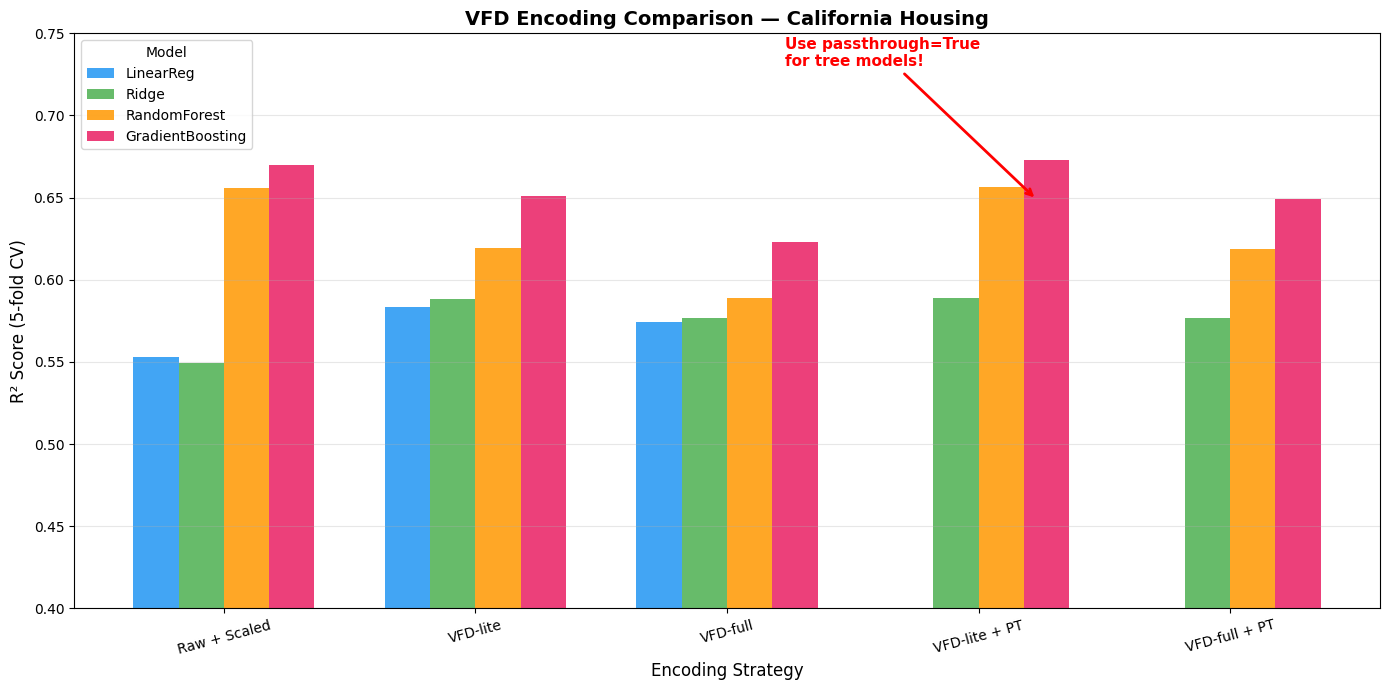

In [7]:
# Grouped bar chart
enc_names = list(pipelines.keys())
model_names = list(models.keys())

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(enc_names))
width = 0.18

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for i, model_name in enumerate(model_names):
    scores = [results[(enc, model_name)] for enc in enc_names]
    bars = ax.bar(x + i * width, scores, width, label=model_name, color=colors[i], alpha=0.85)

ax.set_xlabel('Encoding Strategy', fontsize=12)
ax.set_ylabel('R² Score (5-fold CV)', fontsize=12)
ax.set_title('VFD Encoding Comparison — California Housing', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(enc_names, rotation=15)
ax.legend(title='Model', loc='upper left')
ax.set_ylim(0.4, 0.75)
ax.grid(axis='y', alpha=0.3)

# Annotate passthrough benefit
ax.annotate('Use passthrough=True\nfor tree models!',
            xy=(3.5, results.get(('VFD-full + PT', 'GradientBoosting'), 0.69)),
            xytext=(2.5, 0.73),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('vfd_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Key Findings

**VFD encoding provides multi-scale numeric features:**

- **Linear models** see consistent improvement (+3–5% R²) because VFD adds non-linear feature interactions that linear models can't create themselves.
- **Tree models without passthrough** perform *worse* because VFD replaces the raw features — trees lose direct access to the original splits.
- **Tree models with `passthrough=True`** get the *best of both worlds*: original features for splitting + VFD features for additional signal.

**Rule of thumb:** Always use `passthrough=True` when combining VFD with tree-based models (Random Forest, Gradient Boosting, XGBoost).

## 3. MCE Temporal Benchmark

The Maya Calendar Encoder captures multi-scale temporal cycles. We test it on
synthetic time series with planted 13-day, 20-day, and 365-day cycles.

In [8]:
from datetime import datetime, timedelta
from maya_encoding import MayaCalendarEncoder

# Generate synthetic temporal data with planted cycles
np.random.seed(42)
n_days = 1000
base = datetime(2020, 1, 1)
dates = np.array([(base + timedelta(days=int(i))).strftime('%Y-%m-%d') for i in range(n_days)])
days = np.arange(n_days, dtype=float)

# Target: combination of 13-day, 20-day, and 365-day cycles + noise
y_temp = (
    2.0 * np.sin(2 * np.pi * days / 13) +     # Tzolk'in trecena
    1.5 * np.sin(2 * np.pi * days / 20) +     # Tzolk'in veintena
    3.0 * np.sin(2 * np.pi * days / 365) +    # Haab' yearly
    np.random.normal(0, 0.5, n_days)
)

# Test 4 MCE configurations
mce_configs = {
    'All + cyclical': MayaCalendarEncoder(components=['tzolkin', 'haab', 'long_count'], cyclical=True),
    'Tzolkin only': MayaCalendarEncoder(components=['tzolkin'], cyclical=True),
    'Haab only': MayaCalendarEncoder(components=['haab'], cyclical=True),
    'Long Count only': MayaCalendarEncoder(components=['long_count'], cyclical=True),
}

split = int(n_days * 0.7)
print(f'Train: {split} days, Test: {n_days - split} days\n')

from sklearn.ensemble import GradientBoostingRegressor as GBR

for name, mce in mce_configs.items():
    pipe = Pipeline([
        ('encode', mce),
        ('model', GBR(n_estimators=200, random_state=42))
    ])
    pipe.fit(dates[:split].reshape(-1, 1), y_temp[:split])
    train_r2 = pipe.score(dates[:split].reshape(-1, 1), y_temp[:split])
    test_r2 = pipe.score(dates[split:].reshape(-1, 1), y_temp[split:])
    print(f'{name:20s}: Train R²={train_r2:.4f}  Test R²={test_r2:.4f}')

Train: 700 days, Test: 300 days

All + cyclical      : Train R²=0.9855  Test R²=0.9440
Tzolkin only        : Train R²=0.4212  Test R²=0.2362
Haab only           : Train R²=0.8124  Test R²=0.4489
Long Count only     : Train R²=0.7833  Test R²=0.3344


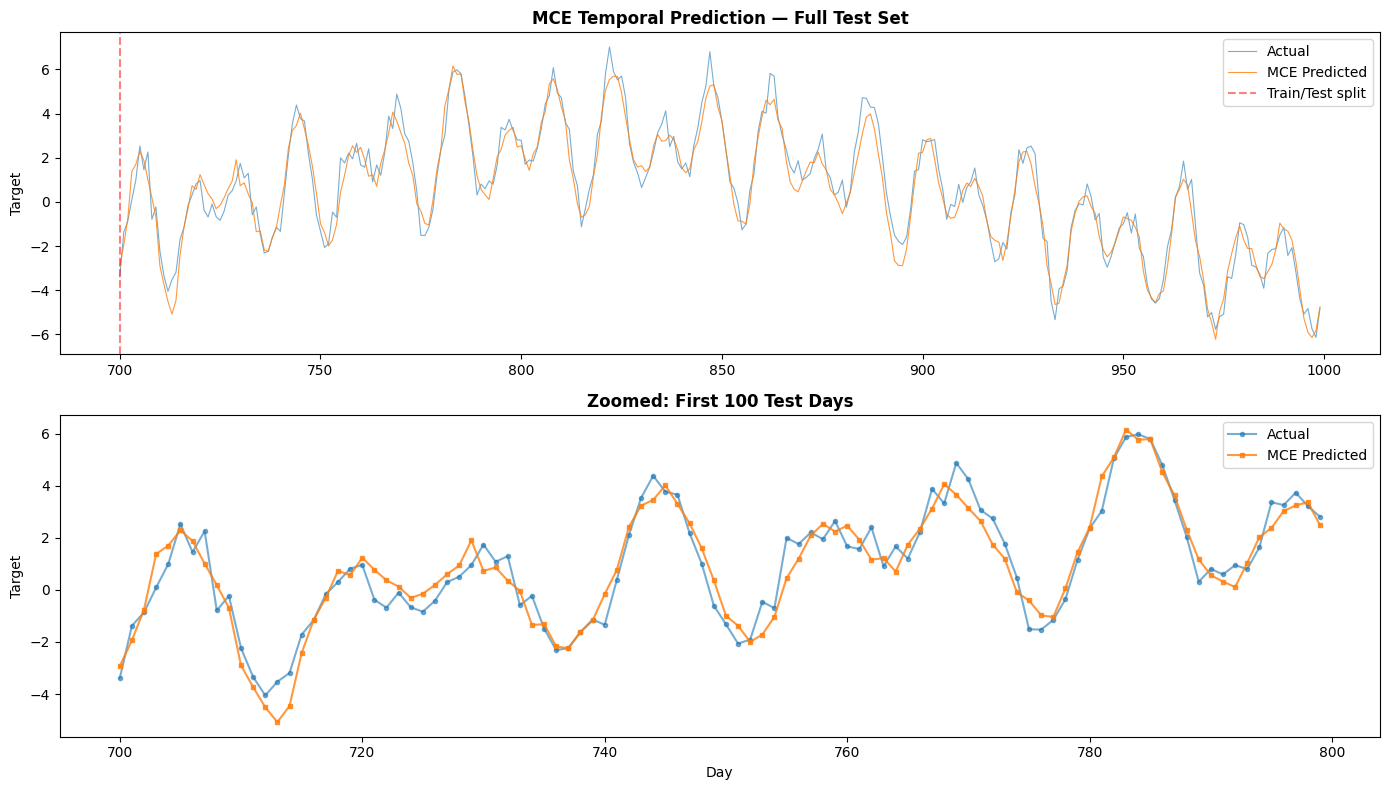

In [9]:
# Visualize predictions vs actual
best_pipe = Pipeline([
    ('encode', MayaCalendarEncoder(components=['tzolkin', 'haab', 'long_count'], cyclical=True)),
    ('model', GBR(n_estimators=200, random_state=42))
])
best_pipe.fit(dates[:split].reshape(-1, 1), y_temp[:split])
y_pred = best_pipe.predict(dates[split:].reshape(-1, 1))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full view
axes[0].plot(range(split, n_days), y_temp[split:], alpha=0.6, label='Actual', linewidth=0.8)
axes[0].plot(range(split, n_days), y_pred, alpha=0.8, label='MCE Predicted', linewidth=0.8)
axes[0].axvline(x=split, color='red', linestyle='--', alpha=0.5, label='Train/Test split')
axes[0].set_title('MCE Temporal Prediction — Full Test Set', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Target')

# Zoomed view (first 100 test days)
zoom = 100
axes[1].plot(range(split, split + zoom), y_temp[split:split + zoom], 'o-', markersize=3, alpha=0.6, label='Actual')
axes[1].plot(range(split, split + zoom), y_pred[:zoom], 's-', markersize=3, alpha=0.8, label='MCE Predicted')
axes[1].set_title(f'Zoomed: First {zoom} Test Days', fontweight='bold')
axes[1].legend()
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Target')

plt.tight_layout()
plt.savefig('mce_temporal_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Summary & Recommendations

| Scenario | Recommendation |
|----------|---------------|
| Linear/Ridge regression | Use VFD directly (components='full' or 'lite') |
| Random Forest / GBM / XGBoost | Use VFD with `passthrough=True` |
| Temporal prediction | Use MCE with all components + `cyclical=True` |
| Only specific cycles matter | Use MCE with targeted `components` |

For comprehensive benchmarks with more models and cross-validation details, run:
```bash
python benchmarks/run_vfd_benchmarks.py
python benchmarks/run_mce_benchmarks.py
```